# 04 - Gaussian Discriminant Analysis: LDA and QDA (Person 2)
**Task:** predict whether a mortgage is fully prepaid within 24 months (`1`) or not (`0`).
Uses the **saved** processed files only; no re-preprocessing, no new split.

In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

In [5]:
# ---- Paths: works whether Jupyter is started in the project root or in notebooks/ ----
import os
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
METRICS_DIR = os.path.join(PROJECT_ROOT, "results", "metrics")
PRED_DIR = os.path.join(PROJECT_ROOT, "results", "predictions")
CM_DIR = os.path.join(PROJECT_ROOT, "results", "confusion_matrices")
for d in (METRICS_DIR, PRED_DIR, CM_DIR):
    os.makedirs(d, exist_ok=True)
RANDOM_STATE = 42

## 1. Load and verify the data

In [6]:
# ---- Load the SAVED processed files (no re-preprocessing, no new split) ----
X_train = pd.read_csv(os.path.join(PROCESSED, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED, "y_test.csv")).squeeze("columns")

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Same feature names and order in train and test:", list(X_train.columns) == list(X_test.columns))
print("Rows match targets:", len(X_train) == len(y_train), len(X_test) == len(y_test))
print("Missing values in X (train/test):", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))
print("Target values:", sorted(y_train.unique()), "(1 = prepaid within 24 months = positive class)")
print("Class balance train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance test :", y_test.value_counts(normalize=True).round(3).to_dict())

# These numbers come from the assignment text; the notebook only warns if the files differ.
expected = {"train": 39288, "test": 9823, "features": 20}
if (len(X_train), len(X_test), X_train.shape[1]) != (expected["train"], expected["test"], expected["features"]):
    print("WARNING: shapes differ from the 39,288 / 9,823 / 20 described in the assignment. Check the files.")
assert list(X_train.columns) == list(X_test.columns), "Feature columns differ between train and test"
assert len(X_train) == len(y_train) and len(X_test) == len(y_test), "Feature/target length mismatch"

X_train: (39288, 20) | X_test: (9823, 20)
y_train: (39288,) | y_test: (9823,)
Same feature names and order in train and test: True
Rows match targets: True True
Missing values in X (train/test): 0 0
Target values: [np.int64(0), np.int64(1)] (1 = prepaid within 24 months = positive class)
Class balance train: {1: 0.524, 0: 0.476}
Class balance test : {1: 0.524, 0: 0.476}


## 2. Check covariance stability (training data only)
Before fitting QDA we inspect each class covariance matrix. Only the **training** set is used, so this does not leak test information.

In [7]:
X_tr = X_train.values
for k in (0, 1):
    Xk = X_tr[y_train.values == k]
    cov = np.cov(Xk, rowvar=False)
    eig = np.linalg.eigvalsh(cov)
    print(f"Class {k}: n={len(Xk):,} | rank={np.linalg.matrix_rank(cov)}/{cov.shape[0]} | "
          f"min eigenvalue={eig.min():.2e} | max eigenvalue={eig.max():.2e} | "
          f"condition number={eig.max() / max(eig.min(), 1e-300):.2e}")

# Features with (almost) zero variance inside a class make that class covariance singular.
low_var = {k: X_train.columns[X_tr[y_train.values == k].std(axis=0) < 1e-8].tolist() for k in (0, 1)}
print("Constant features within class:", low_var)

# One-hot groups that sum to exactly 1 are perfectly collinear (the 'dummy variable trap').
corr = np.corrcoef(X_tr, rowvar=False)
np.fill_diagonal(corr, 0)
print("Max absolute pairwise correlation between features:", np.nanmax(np.abs(corr)).round(3))

Class 0: n=18,689 | rank=20/20 | min eigenvalue=2.72e-03 | max eigenvalue=2.32e+00 | condition number=8.53e+02
Class 1: n=20,599 | rank=20/20 | min eigenvalue=2.42e-04 | max eigenvalue=1.92e+00 | condition number=7.93e+03
Constant features within class: {0: [], 1: []}
Max absolute pairwise correlation between features: 0.819


Read the output above and note it in your report. A tiny minimum eigenvalue, rank below the number of features, or a very large condition number means plain QDA is unstable on this data, which justifies the modest regularisation used below.

## 3. Linear GDA (LDA)

In [8]:
lda = LinearDiscriminantAnalysis()          # default 'svd' solver, shared covariance
lda.fit(X_train, y_train)
lda_pred = lda.predict(X_test)
lda_scores = lda.decision_function(X_test)  # log-odds of class 1 (continuous)
print("Predicted class counts:", pd.Series(lda_pred).value_counts().to_dict())
print("Class priors estimated from training data:", dict(zip(lda.classes_.tolist(), lda.priors_.round(3).tolist())))

Predicted class counts: {1: 5192, 0: 4631}
Class priors estimated from training data: {0: 0.476, 1: 0.524}


## 4. Quadratic GDA (QDA)
`reg_param=0.1` is fixed in advance from the assignment guidance and the stability check above. It is **not** tuned on the test set. We record any warnings sklearn raises so nothing is hidden.

In [9]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
    qda.fit(X_train, y_train)
print("Warnings during QDA fit:", [str(w.message) for w in caught] or "none")

qda_pred = qda.predict(X_test)
qda_scores = qda.predict_log_proba(X_test)[:, 1] - qda.predict_log_proba(X_test)[:, 0]  # log-odds, continuous
print("Any non-finite scores:", (~np.isfinite(qda_scores)).any())
print("Predicted class counts:", pd.Series(qda_pred).value_counts().to_dict())

Warnings during QDA fit: none
Any non-finite scores: False
Predicted class counts: {1: 6405, 0: 3418}


If the warnings list is not empty, or there are non-finite scores, state that in the report. If a minimal correction is needed (for example removing one dummy column from each one-hot group), apply it to **both** LDA and QDA, document it, and note that it changes the feature set relative to the shared preprocessing.

## 5. Evaluation (positive class = 1)

In [10]:
def evaluate(model_name, y_true, y_pred, scores):
    """Same metric definitions for every model. Positive class = 1 (prepayment)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),   # continuous scores, NOT hard 0/1 predictions
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "n_test": int(len(y_true)),
    }


def plot_confusion(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No prepayment (0)", "Prepayment (1)"])
    ax.set_yticklabels(["No prepayment (0)", "Prepayment (1)"])
    ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual class"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show(); plt.close(fig)

In [11]:
lda_metrics = evaluate("GDA - Linear (LDA)", y_test, lda_pred, lda_scores)
qda_metrics = evaluate("GDA - Quadratic (QDA, reg_param=0.1)", y_test, qda_pred, qda_scores)
results_df = pd.DataFrame([lda_metrics, qda_metrics])
print(results_df.round(4).to_string(index=False))
print()
print("Majority-class baseline accuracy:", round(max(y_test.mean(), 1 - y_test.mean()), 4))

                               model  accuracy  precision  recall     f1  roc_auc   tn   fp   fn   tp  n_test
                  GDA - Linear (LDA)    0.6472     0.6622  0.6676 0.6649   0.7003 2919 1754 1712 3438    9823
GDA - Quadratic (QDA, reg_param=0.1)    0.6289     0.6175  0.7680 0.6846   0.6877 2223 2450 1195 3955    9823

Majority-class baseline accuracy: 0.5243


### 6. Save metrics, predictions and confusion matrices

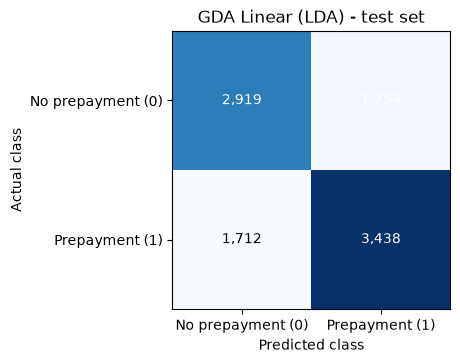

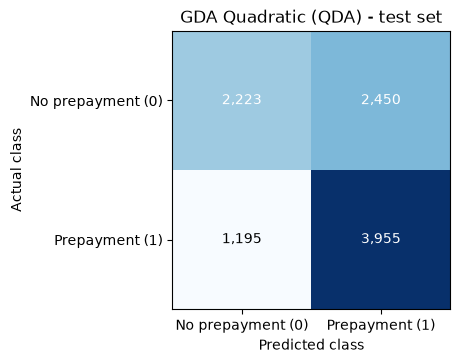

saved   p:\ML-Mini-Project\results\metrics/gda_linear_metrics.csv
saved   p:\ML-Mini-Project\results\metrics/gda_quadratic_metrics.csv
saved   p:\ML-Mini-Project\results\predictions/gda_linear_predictions.csv
saved   p:\ML-Mini-Project\results\predictions/gda_quadratic_predictions.csv
saved   p:\ML-Mini-Project\results\confusion_matrices/gda_linear_confusion_matrix.png
saved   p:\ML-Mini-Project\results\confusion_matrices/gda_quadratic_confusion_matrix.png


In [12]:
pd.DataFrame([lda_metrics]).to_csv(os.path.join(METRICS_DIR, "gda_linear_metrics.csv"), index=False)
pd.DataFrame([qda_metrics]).to_csv(os.path.join(METRICS_DIR, "gda_quadratic_metrics.csv"), index=False)

pd.DataFrame({"row_index": X_test.index, "y_true": y_test.values, "y_pred": lda_pred,
              "decision_score": lda_scores,
              "prob_class1": lda.predict_proba(X_test)[:, 1]}).to_csv(
    os.path.join(PRED_DIR, "gda_linear_predictions.csv"), index=False)
pd.DataFrame({"row_index": X_test.index, "y_true": y_test.values, "y_pred": qda_pred,
              "decision_score": qda_scores,
              "prob_class1": qda.predict_proba(X_test)[:, 1]}).to_csv(
    os.path.join(PRED_DIR, "gda_quadratic_predictions.csv"), index=False)

plot_confusion(y_test, lda_pred, "GDA Linear (LDA) - test set", os.path.join(CM_DIR, "gda_linear_confusion_matrix.png"))
plot_confusion(y_test, qda_pred, "GDA Quadratic (QDA) - test set", os.path.join(CM_DIR, "gda_quadratic_confusion_matrix.png"))

for f in ("metrics/gda_linear_metrics.csv", "metrics/gda_quadratic_metrics.csv",
          "predictions/gda_linear_predictions.csv", "predictions/gda_quadratic_predictions.csv",
          "confusion_matrices/gda_linear_confusion_matrix.png", "confusion_matrices/gda_quadratic_confusion_matrix.png"):
    p = os.path.join(PROJECT_ROOT, "results", f)
    print(("saved   " if os.path.exists(p) else "MISSING ") + p)

## 7. Save results in the shared `results/` layout
Writes the confusion matrix CSV, metrics JSON, test predictions CSV, and the confusion-matrix and ROC plots for both LDA (`gda_linear`) and QDA (`gda_quadratic`) using the same file names as the other models.

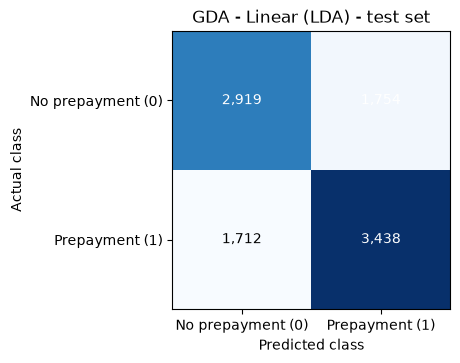

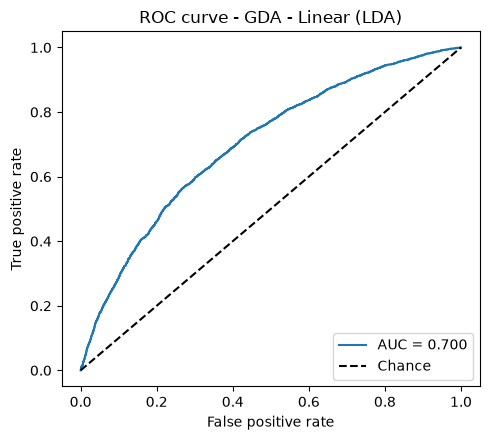

saved results for 'gda_linear' to confusion_matrices/, metrics/ and plots/


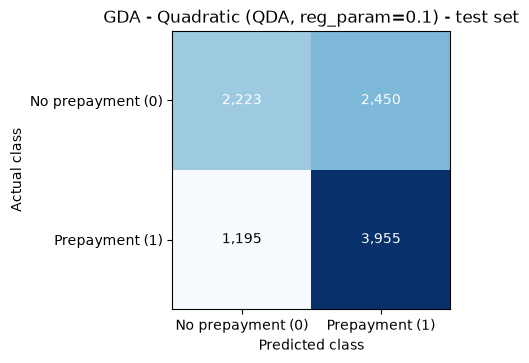

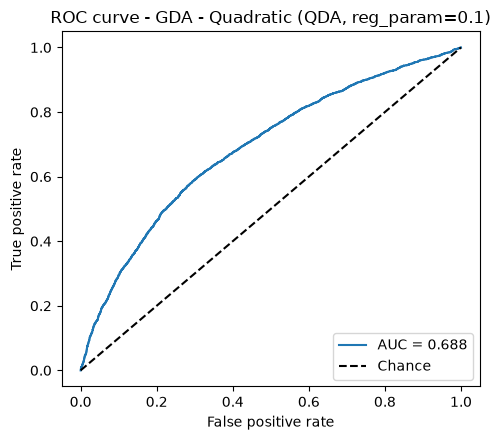

saved results for 'gda_quadratic' to confusion_matrices/, metrics/ and plots/


In [13]:
import json
from sklearn.metrics import roc_curve

PLOTS_DIR = os.path.join(PROJECT_ROOT, "results", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)


def save_in_team_format(name, y_true, y_pred, scores, metrics, extra_cols=None):
    """Save one model's results in the shared results/ layout:
    confusion_matrices/<name>_confusion_matrix.csv
    metrics/<name>_metrics.json, metrics/<name>_test_predictions.csv
    plots/<name>_confusion_matrix.png, plots/<name>_roc_curve.png
    """
    # 1) confusion matrix as CSV (rows = actual, columns = predicted)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]).to_csv(
        os.path.join(CM_DIR, f"{name}_confusion_matrix.csv"))

    # 2) metrics as JSON
    with open(os.path.join(METRICS_DIR, f"{name}_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2, default=float)

    # 3) test predictions as CSV
    out = {"row_index": np.arange(len(y_true)), "y_true": np.asarray(y_true),
           "y_pred": np.asarray(y_pred), "decision_score": np.asarray(scores)}
    if extra_cols:
        out.update(extra_cols)
    pd.DataFrame(out).to_csv(os.path.join(METRICS_DIR, f"{name}_test_predictions.csv"), index=False)

    # 4) plots: confusion matrix and ROC curve
    plot_confusion(y_true, y_pred, f"{metrics['model']} - test set",
                   os.path.join(PLOTS_DIR, f"{name}_confusion_matrix.png"))
    fpr, tpr, _ = roc_curve(y_true, scores)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", label="Chance")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC curve - {metrics['model']}"); ax.legend(loc="lower right")
    fig.tight_layout(); fig.savefig(os.path.join(PLOTS_DIR, f"{name}_roc_curve.png"), dpi=150)
    plt.show(); plt.close(fig)
    print(f"saved results for '{name}' to confusion_matrices/, metrics/ and plots/")

save_in_team_format("gda_linear", y_test.values, lda_pred, lda_scores, lda_metrics,
                    extra_cols={"prob_class1": lda.predict_proba(X_test)[:, 1]})
save_in_team_format("gda_quadratic", y_test.values, qda_pred, qda_scores, qda_metrics,
                    extra_cols={"prob_class1": qda.predict_proba(X_test)[:, 1]})


## 8. Interpretation

**Covariance check (training data only).** Both class covariance matrices are full rank (20/20), have no constant features, and QDA fitted with no warnings and no non-finite scores. The smallest eigenvalues are small but not zero (2.7e-03 for class 0, 2.4e-04 for class 1). The condition number is about 10 times higher for class 1 (7.9e+03) than for class 0 (8.5e+02), and the largest pairwise feature correlation is 0.82. So the covariances are usable but class 1 is the less stable one, which is why a modest `reg_param=0.1` was fixed in advance. It was not tuned on the test set.

**LDA vs QDA (class 1 = prepayment).**

| | LDA | QDA | Higher |
|---|---|---|---|
| Accuracy | 0.6472 | 0.6289 | LDA |
| Precision | 0.6622 | 0.6175 | LDA |
| Recall | 0.6676 | 0.7680 | QDA |
| F1 | 0.6649 | 0.6846 | QDA |
| ROC-AUC | 0.7003 | 0.6877 | LDA |

- QDA's extra flexibility does **not** help overall. It wins on recall and F1 but loses on accuracy, precision and ROC-AUC. The paired bootstrap in `06_model_comparison` puts the AUC gap (LDA minus QDA) at about 0.013 (95% interval roughly 0.007 to 0.018), so it is not noise.
- QDA's higher recall comes mainly from predicting "prepay" more often: it labels 6,405 of 9,823 test loans (65%) as prepaid, versus 5,192 (53%) for LDA, when the true share is 52%. ROC-AUC does not depend on the decision threshold, and QDA's is lower, so QDA does not rank loans better than LDA. It just sits at a different point on the precision/recall trade-off. We did not test whether overfitting or covariance instability is the cause.

**False positives vs false negatives.**
- LDA is balanced: 1,754 false positives (predicted prepay, did not) and 1,712 false negatives (missed a real prepayment).
- QDA shifts the errors: false negatives fall to 1,195 (about 30% fewer than LDA) but false positives rise to 2,450 (about 40% more), so it makes roughly twice as many false alarms as misses.
- Raising recall costs precision here. Which model is preferable depends on whether a missed prepayment or a false alarm is the costlier mistake.

**Accuracy vs the majority baseline (0.5243).** LDA beats the baseline by about 12 points and QDA by about 10, so both find real signal, but the gain is modest. Accuracy alone also hides the trade-off above (QDA has lower accuracy but finds more prepayments), so precision, recall, F1 and ROC-AUC should be read together.

**Compared with the other models** (see `06_model_comparison`): LDA is practically the same as Logistic Regression (accuracy 0.6472 vs 0.6474, ROC-AUC 0.7003 vs 0.7004), which is expected since both give a linear boundary. The Neural Network (accuracy 0.657, ROC-AUC 0.709) and the RBF SVM (0.653, 0.707) are slightly higher, and QDA is the lowest on accuracy and ROC-AUC.

**Limitations.**
- GDA assumes roughly Gaussian features, but 11 of the 20 columns are 0/1 (one-hot and binary), which cannot be Gaussian, so the model assumptions hold only approximately.
- Features are correlated (maximum absolute correlation 0.82).
- LDA's single shared covariance assumes both classes have the same spread, which may not hold.
- QDA depends on the chosen `reg_param` (0.1, fixed and not tuned), and its class-1 covariance is the less stable one.
- Everything is based on one train/test split and one seed.